### Initialisation

In [62]:
import importlib    
import AOT_biomaps
from AOT_biomaps import AOT_Acoustic
from AOT_biomaps import AOT_Optic
from AOT_biomaps import AOT_AOsignal
from AOT_biomaps import AOT_reconstruction

importlib.reload(AOT_biomaps)
importlib.reload(AOT_Acoustic)
importlib.reload(AOT_Optic)
importlib.reload(AOT_AOsignal)
importlib.reload(AOT_reconstruction)

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time



### Optic Image $\lambda$

In [ ]:
absorbers = [
    {'center': (1/1000, 17.5/1000), 'radius': 0.9/1000},  # Absorbeur 1
    {'center': (3.1/1000, 21/1000), 'radius': 1.5*0.9/1000},  # Absorbeur 2
]

dx = 0.2/1000
dz = dx

x = np.arange(-20/1000,20/1000,dx)
z = np.arange(0, 37/1000,dz)
center = (0, len(x) * dz / 2)

laser_intensity = AOT_Optic.gaussian_beam(x, z, center)

LAMBDA = AOT_Optic.add_absorbers(laser_intensity, x, z, absorbers)

plt.figure(figsize=(5, 5))
plt.imshow(LAMBDA, extent=(x[0]*1000, x[-1]*1000+1, z[-1]*1000, z[0]*1000), aspect='auto', cmap='hot')
plt.title(r"Optic image to reconstruct ($\lambda$ )")

plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
plt.tick_params(axis='both', which='major', labelsize=15)
plt.show()


### System Matrix ($A$)

In [ ]:
systemMatrixListPath = []
baseSystemMatrixPath = "C:/Users/duclos/Desktop/AcoustoOpticTomography/reconExample/PlaneWave/system_matrix"
active_list = "f"*48 # Plane wave (no structuration)
angles = [-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10] # angles in degrees

for nbScan in range(len(angles)):
    angle = angles[nbScan]
    if angle < 0:
        if angle < -9:
            angleString = "1"+str(abs(angle))
        else:
             angleString = "10"+str(abs(angle))
    else:
        if angle > 9:
            angleString = "0"+str(abs(angle))
        else:
            angleString = "00"+str(abs(angle))
    systemMatrixListPath.append(baseSystemMatrixPath+"/field_" + active_list + "_" + angleString + ".hdr")
    

A_matrix = np.zeros((905, len(z), len(x) , len(systemMatrixListPath)), dtype=np.float32)

for i in range(len(systemMatrixListPath)):
    A_matrix[:,:,:,i] = AOT_Acoustic.load_fieldKWAVE_XZ(systemMatrixListPath[i])



test = A_matrix[:,:,:,0] # take the first angle for the example

times = 400
plt.figure(figsize=(5, 5))
plt.imshow(test[times,:,:], extent=(x[0]*1000, x[-1]*1000+1, z[-1]*1000, z[0]*1000), aspect='auto', cmap='jet')
plt.title(r"System matrix ($A$) at time = " + str(times*25e-6*1000) + " ms")
plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
plt.tick_params(axis='both', which='major', labelsize=15)
plt.show()

# plot max pressure field
plt.figure(figsize=(5, 5))
plt.imshow(np.max(test, axis=0), extent=(x[0]*1000, x[-1]*1000+1, z[-1]*1000, z[0]*1000), aspect='auto', cmap='jet',vmax=0.5)
plt.title(r"Max pressure field ($A$ )")
plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
plt.tick_params(axis='both', which='major', labelsize=15)
plt.show()

### AO Signal ($y$)

In [ ]:
y = AOT_AOsignal.getSaveAOsignal(systemMatrixListPath,LAMBDA, A_matrix.T,"C:/Users/duclos/Desktop/AcoustoOpticTomography/reconExample/PlaneWave")

In [ ]:
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.plot(y[:,3])
plt.subplot(132)
plt.imshow(LAMBDA, extent=(x[0]*1000, x[-1]*1000+1, z[-1]*1000, z[0]*1000), aspect='auto', cmap='hot')
plt.subplot(133)
plt.imshow(A_matrix[:,:,:,3][400,:,:], extent=(x[0]*1000, x[-1]*1000+1, z[-1]*1000, z[0]*1000), aspect='auto', cmap='jet')
plt.show()

In [ ]:
nScan = 1

# Création de la figure et des sous-graphiques
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Sous-graphique pour l'animation
im_field = axs[0].imshow(A_matrix[0, :, :, nScan], cmap='jet', origin='upper',
                         extent=(x[0]*1000, x[-1]*1000+1, z[-1]*1000, z[0]*1000), aspect='auto', vmin=0, vmax=0.5)
axs[0].set_title("Interaction champ acoustique \n k-wave / flux de photons (t=25µs)", fontsize=14)
axs[0].set_xlabel("X (mm)", fontsize=14)
axs[0].set_ylabel("Z (mm)", fontsize=14)

# Sous-graphique pour le plot
axs[1].plot(y[:, 3])
axs[1].set_title("Plot de y", fontsize=14)
axs[1].set_xlabel("time", fontsize=14)
axs[1].set_ylabel("Valeur", fontsize=14)

# Création de la ligne verticale
vertical_line = axs[1].axvline(x=500, color='r', linestyle='--')

# Sous-graphique pour l'affichage de LAMBDA
im_lambda = axs[2].imshow(LAMBDA, extent=(x[0]*1000, x[-1]*1000+1, z[-1]*1000, z[0]*1000), cmap='hot', aspect='auto')
axs[2].set_title("Affichage de LAMBDA", fontsize=14)
axs[2].set_xlabel("X (mm)", fontsize=14)
axs[2].set_ylabel("Z (mm)", fontsize=14)

# Affichage pour toutes les frames
for t in range(0,A_matrix.shape[0],50):  # Assurez-vous que l'axe du temps est le premier
    # Mise à jour des données affichées
    im_field.set_data(A_matrix[t, :, :, nScan])
    axs[0].set_title(f"k-wave Acoustic Field (time : {t})", fontsize=14)

    # Mise à jour de la position de la ligne verticale
    vertical_line.set_xdata([t, t])

    # Affichage de la figure mise à jour en temps réel
    display(fig)
    clear_output(wait=True)
    time.sleep(0.1)  # Ajoutez un délai pour ralentir l'animation si nécessaire

plt.close(fig)

### Reconstruction ($\lambda_{recon}$)

In [ ]:
### ONLY ON LINUX ###

imageDir = "C:/Users/duclos/Desktop/AcoustoOpticTomography/TomographyAcoustoOptic/results"
sMatrixDir = "C:/Users/duclos/Desktop/AcoustoOpticTomography/reconExample/PlaneWave/system_matrix"  
AO_path = "C:/Users/duclos/Desktop/AcoustoOpticTomography/reconExample/PlaneWave"
reconExe = "C:/Users/duclos/Desktop/AcoustoOpticTomography/TomographyAcoustoOptic/RECONSTRUCTION/CASToR/bin/castor-recon"
AOT_reconstruction.makeRecon(AO_path, sMatrixDir,imageDir,reconExe)

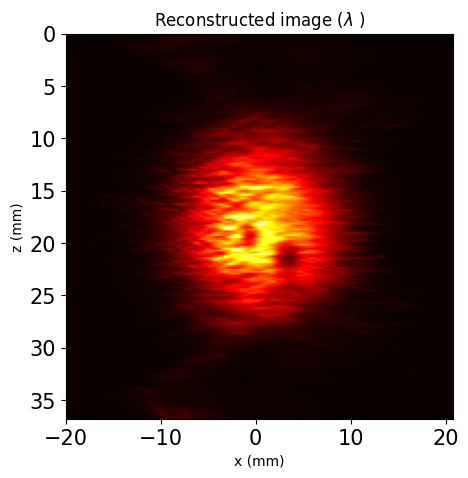

In [63]:
LAMBDA_recon = AOT_reconstruction.read_recon("C:/Users/duclos/Desktop/AcoustoOpticTomography/TomographyAcoustoOptic/results/results_it100.hdr")

plt.figure(figsize=(5, 5))
plt.imshow(LAMBDA_recon, extent=(x[0]*1000, x[-1]*1000+1, z[-1]*1000, z[0]*1000), aspect='auto', cmap='hot')
plt.title(r"Reconstructed image ($\lambda$ )")
plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
plt.tick_params(axis='both', which='major', labelsize=15)
plt.show()